In [1]:
!pip install pandas yfinance tensorflow scikit-learn gspread oauth2client fastapi uvicorn pyngrok nest-asyncio

In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from fastapi import FastAPI

# 1. Inisialisasi FastAPI
app = FastAPI()

# 2. FUNGSI PENCARI TOP 10 SAHAM OTOMATIS (Berdasarkan Market Cap)
def get_dynamic_top_10():
    print("🔄 Mengambil data kapitalisasi pasar terbaru dari Yahoo Finance...")
    # Daftar 25 saham raksasa kandidat (Bluechip/LQ45) agar pencarian cepat
    candidates = [
        'BBCA.JK', 'BBRI.JK', 'BREN.JK', 'BYAN.JK', 'BMRI.JK',
        'AMMN.JK', 'TLKM.JK', 'TPIA.JK', 'BBNI.JK', 'ASII.JK',
        'ICBP.JK', 'UNVR.JK', 'GOTO.JK', 'KLBF.JK', 'ADRO.JK',
        'BRPT.JK', 'CPIN.JK', 'INDF.JK', 'PGAS.JK', 'UNTR.JK',
        'AMRT.JK', 'INKP.JK', 'SMGR.JK', 'AKRA.JK', 'MEDC.JK'
    ]

    stock_data = []
    for ticker in candidates:
        try:
            # Ambil info saham
            info = yf.Ticker(ticker).info
            # Ambil nilai kapitalisasi pasar, pastikan bentuknya angka
            mcap = info.get('marketCap')
            if mcap is not None and mcap > 0:
                stock_data.append({'ticker': ticker, 'mcap': mcap})
        except Exception as e:
            continue # Abaikan jika ada error pada satu saham dan lanjut ke berikutnya

    # Urutkan dari Market Cap terbesar ke terkecil
    stock_data_sorted = sorted(stock_data, key=lambda x: x['mcap'], reverse=True)

    # Ambil 10 teratas
    top_10 = [stock['ticker'] for stock in stock_data_sorted[:10]]
    print(f"✅ Top 10 Saham Terkini Ditemukan: {top_10}")
    return top_10

# Eksekusi pencarian saat server baru menyala
top_10_idx = get_dynamic_top_10()

# 3. FUNGSI PREDIKSI LSTM
def get_forecast_7_days(symbol):
    # Ambil data historis
    df = yf.download(symbol, period='5y', progress=False)
    data = df['Close'].values.reshape(-1, 1)

    # Normalisasi Data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)

    # 1. SIAPKAN DATA UNTUK MENEBAK 7 HARI SEKALIGUS
    X_train, y_train = [], []
    # Kita kurangi 7 di batas akhir agar selalu ada "masa depan" 7 hari untuk dijadikan target belajar
    for i in range(60, len(scaled_data) - 7 + 1):
        X_train.append(scaled_data[i-60:i, 0])
        y_train.append(scaled_data[i:i+7, 0]) # <--- UBAH DI SINI: Ambil array 7 hari ke depan

    X_train, y_train = np.array(X_train), np.array(y_train)
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

    # Bangun Model LSTM
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
        LSTM(50, return_sequences=False),
        Dense(25),
        Dense(7) # <--- UBAH DI SINI: Pintu keluar sekarang mengeluarkan 7 tebakan harga
    ])

    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(X_train, y_train, batch_size=32, epochs=10, validation_split=0.2, verbose=1)

    # 2. PREDIKSI 7 HARI KE DEPAN
    last_60_days = scaled_data[-60:]
    X_test = np.array([last_60_days])
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

    # Model akan mengeluarkan array berisi 7 angka (yang masih dinormalisasi 0-1)
    pred_prices_scaled = model.predict(X_test, verbose=0)

    # Kembalikan ke format Rupiah asli
    pred_prices = scaler.inverse_transform(pred_prices_scaled)[0]

    current_price = float(data[-1].item())

    # Simpan 7 harga tersebut dalam bentuk list
    forecast_7_days = [float(price) for price in pred_prices]

    # Kita hitung potensinya berdasarkan harga di hari ke-7 (hari terakhir prediksi)
    forecast_price_day_7 = forecast_7_days[-1]
    potential_growth_7d = ((forecast_price_day_7 - current_price) / current_price) * 100

    return current_price, forecast_7_days, potential_growth_7d

# 4. BUAT "TOPLES" UNTUK MENYIMPAN HASIL PREDIKSI
cached_predictions = []

# 5. FUNGSI UNTUK "MEMASAK" SEMUA PREDIKSI DI AWAL
def generate_all_predictions():
    global cached_predictions
    print("\n⏳ Mulai melatih model LSTM (Prediksi 7 Hari) dan mengambil profil perusahaan...")

    temp_results = []
    for stock in top_10_idx:
        try:
            print(f"   Memproses {stock}...")

            # --- AMBIL PROFIL ---
            info = yf.Ticker(stock).info
            nama_pt = info.get('longName', 'Tidak diketahui')
            sektor = info.get('sector', 'Sektor Umum')

            # --- PREDIKSI 7 HARI ---
            # Pastikan Anda memanggil fungsi get_forecast_7_days yang baru kita buat
            curr, forecast_7d, grow = get_forecast_7_days(stock)

            # Bulatkan 7 harga prediksi agar tidak terlalu panjang komanya (misal: 6900.12345 -> 6900.12)
            forecast_7d_rounded = [round(price, 2) for price in forecast_7d]

            # Masukkan semua data lengkap ke dalam toples
            temp_results.append({
                "ticker": stock.replace(".JK", ""),
                "nama_perusahaan": nama_pt,
                "sektor_bisnis": sektor,
                "harga_saat_ini": round(curr, 2),
                "prediksi_7_hari": forecast_7d_rounded, # Masukkan list 7 hari
                "potential_7_hari": round(grow, 2)      # Potensi di hari ke-7
            })
        except Exception as e:
            print(f"❌ Gagal memprediksi {stock}: {e}")

    cached_predictions = temp_results
    print("✅ SEMUA PREDIKSI 7 HARI & PROFIL DISIMPAN DI MEMORI!\n")

# Eksekusi saat Colab/Server dinyalakan
generate_all_predictions()

# 6. ENDPOINT API (Sekarang super cepat!)
@app.get("/predict-top-10")
def predict_all():
    # Cukup berikan isi toples tanpa perlu ngetrain ulang
    if not cached_predictions:
        return {"error": "Data sedang diproses, coba lagi sebentar."}
    return cached_predictions

print("📊 HASIL PREDIKSI POTENSI SAHAM TOP 10 (7 HARI KE DEPAN):\n")

# Cek apakah toples sudah terisi
if not cached_predictions:
    print("⚠️ Data belum siap. Pastikan generate_all_predictions() sudah selesai dijalankan.")
else:
    # Mengurutkan dari potensi (potential_7_hari) tertinggi ke terendah
    sorted_predictions = sorted(cached_predictions, key=lambda x: x['potential_7_hari'], reverse=True)

    for data in sorted_predictions:
        print(f"Ticker: {data['ticker']} | Perusahaan: {data['nama_perusahaan']}")
        print(f" └─ Harga Saat Ini : Rp {data['harga_saat_ini']:,.2f}")
        print(f" └─ Prediksi 7 Hari: {data['prediksi_7_hari']}")
        print(f" └─ Potensi (H-7)  : {data['potential_7_hari']}%")
        print("-" * 55)

🔄 Mengambil data kapitalisasi pasar terbaru dari Yahoo Finance...
✅ Top 10 Saham Terkini Ditemukan: ['BREN.JK', 'BBCA.JK', 'BBRI.JK', 'TPIA.JK', 'BMRI.JK', 'AMMN.JK', 'BYAN.JK', 'TLKM.JK', 'ASII.JK', 'BBNI.JK']

⏳ Mulai melatih model LSTM (Prediksi 7 Hari) dan mengambil profil perusahaan...
   Memproses BREN.JK...
Epoch 1/10


/tmp/ipykernel_633/2909947131.py:50: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, period='5y', progress=False)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.3324 - val_loss: 0.0678
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0494 - val_loss: 0.0287
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0208 - val_loss: 0.0044
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0151 - val_loss: 0.0055
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0143 - val_loss: 0.0053
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0145 - val_loss: 0.0053
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0139 - val_loss: 0.0055
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0143 - val_loss: 0.0033
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0133 - val_loss: 0.0046
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0133 - val_loss: 0.0029
   Memproses BBCA.JK...


/tmp/ipykernel_633/2909947131.py:50: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, period='5y', progress=False)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.2022 - val_loss: 0.0109
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0054 - val_loss: 0.0068
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0027 - val_loss: 0.0062
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0027 - val_loss: 0.0069
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0023 - val_loss: 0.0072
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0023 - val_loss: 0.0071
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0022 - val_loss: 0.0060
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0021 - val_loss: 0.0058
Epoch 9/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0021 - val_loss: 0.0062
Epoch 10/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0021 - val_loss: 0.0062
   Memproses BBRI.JK...
Epoch 1/10


...

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.1672 - val_loss: 0.0092
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0099 - val_loss: 0.0074
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0059 - val_loss: 0.0074
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0055 - val_loss: 0.0085
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0052 - val_loss: 0.0072
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0051 - val_loss: 0.0071
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0051 - val_loss: 0.0070
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0048 - val_loss: 0.0068
Epoch 9/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0044 - val_loss: 0.0083
Epoch 10/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0047 - val_loss: 0.0072
   Memproses ASII.JK...


/tmp/ipykernel_633/2909947131.py:50: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, period='5y', progress=False)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0430 - val_loss: 0.0151
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0034 - val_loss: 0.0051
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0024 - val_loss: 0.0043
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0021 - val_loss: 0.0078
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0018 - val_loss: 0.0072
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0018 - val_loss: 0.0056
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0019 - val_loss: 0.0073
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0018 - val_loss: 0.0034
Epoch 9/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0018 - val_loss: 0.0045
Epoch 10/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0018 - val_loss: 0.0042
   Memproses BBNI.JK...
Epoch 1/10


/tmp/ipykernel_633/2909947131.py:50: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, period='5y', progress=False)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.1611 - val_loss: 0.0057
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0068 - val_loss: 0.0035
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0037 - val_loss: 0.0041
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0034 - val_loss: 0.0034
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0036 - val_loss: 0.0039
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0036 - val_loss: 0.0036
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0031 - val_loss: 0.0036
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0033 - val_loss: 0.0033
Epoch 9/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0031 - val_loss: 0.0033
Epoch 10/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0032 - val_loss: 0.0035
✅ SEMUA PREDIKSI 7 HARI & PROFIL DISIMPAN DI MEMORI!

📊 HASIL PREDIKSI POTENSI SAHAM TOP 10 (7 HARI KE DEPAN):

Ticker: AMMN | Perusahaan: PT Amman Mineral Inte

📊 Mengambil data historis BBCA.JK untuk analisis EDA...


/tmp/ipykernel_633/4091362318.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='5y', progress=False)


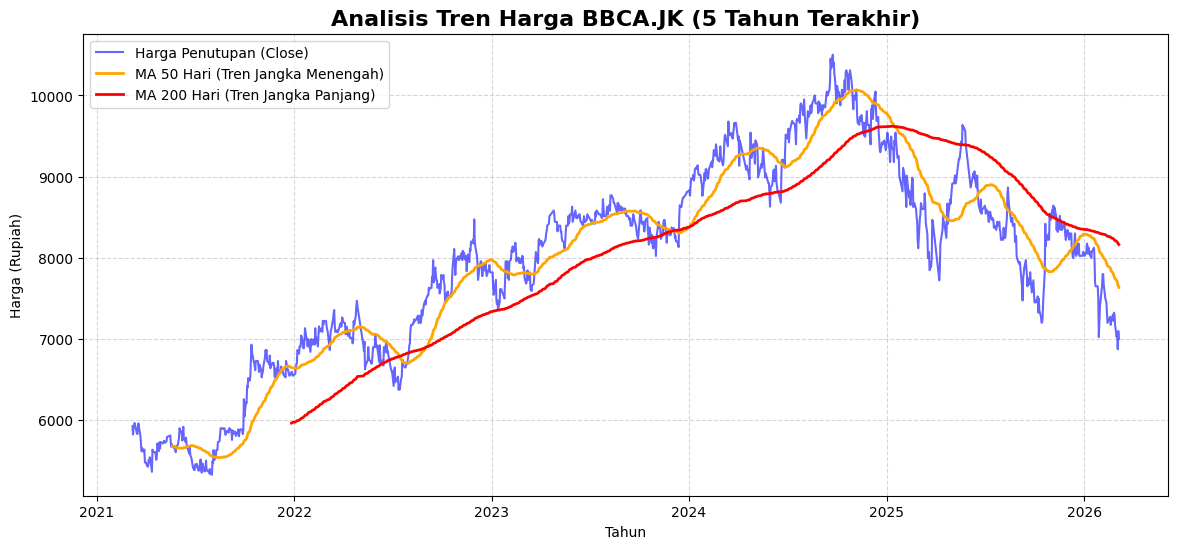

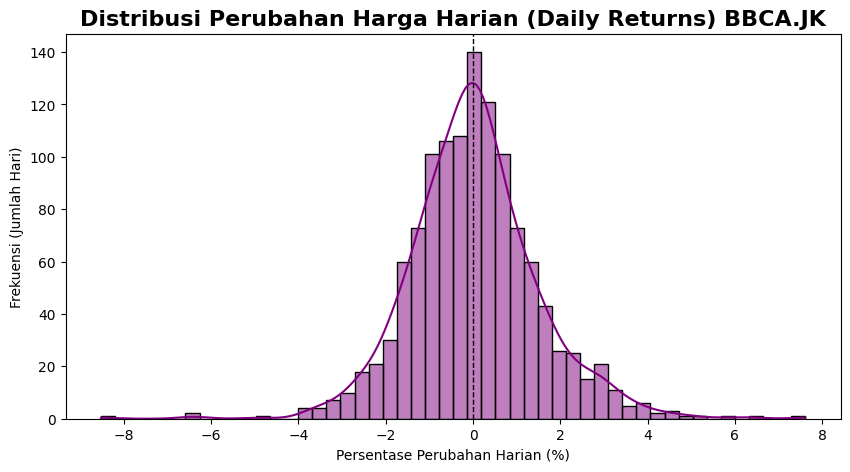


✅ Analisis Visual Selesai!


In [10]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP DATA
ticker = 'BBCA.JK' # Bisa Anda ganti dengan saham lain dari top 10 Anda
print(f"📊 Mengambil data historis {ticker} untuk analisis EDA...")
df = yf.download(ticker, period='5y', progress=False)

# Cek dan bersihkan data kosong (Missing Values/NaN)
if df.isnull().values.any():
    print("⚠️ Ditemukan data kosong (NaN). Membersihkan data...")
    df = df.dropna()

# 2. FEATURE ENGINEERING (Membuat data baru untuk analisis)
# Menghitung Moving Average 50 hari dan 200 hari untuk melihat Trend
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

# Menghitung Daily Returns (Persentase perubahan harga harian) untuk melihat Volatilitas
df['Daily_Return'] = df['Close'].pct_change() * 100

# 3. VISUALISASI 1: GRAFIK TREN HARGA & MOVING AVERAGE
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Harga Penutupan (Close)', color='blue', alpha=0.6)
plt.plot(df.index, df['MA50'], label='MA 50 Hari (Tren Jangka Menengah)', color='orange', linewidth=2)
plt.plot(df.index, df['MA200'], label='MA 200 Hari (Tren Jangka Panjang)', color='red', linewidth=2)

plt.title(f'Analisis Tren Harga {ticker} (5 Tahun Terakhir)', fontsize=16, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Harga (Rupiah)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 4. VISUALISASI 2: HISTOGRAM PERSEBARAN DATA (VOLATILITAS)
plt.figure(figsize=(10, 5))
# Menggunakan Seaborn untuk membuat histogram yang lebih cantik dengan garis kurva (KDE)
sns.histplot(df['Daily_Return'].dropna(), bins=50, kde=True, color='purple')

plt.title(f'Distribusi Perubahan Harga Harian (Daily Returns) {ticker}', fontsize=16, fontweight='bold')
plt.xlabel('Persentase Perubahan Harian (%)')
plt.ylabel('Frekuensi (Jumlah Hari)')
plt.axvline(0, color='black', linestyle='dashed', linewidth=1) # Garis batas nol (0%)
plt.show()

print("\n✅ Analisis Visual Selesai!")

In [ ]:
import os
import threading
import nest_asyncio
import uvicorn
import time

# 5. MENJALANKAN SERVER & TUNNEL CLOUDFLARE
def kill_port(port):
    try:
        os.system(f"fuser -k {port}/tcp")
    except:
        pass

def run_api():
    try:
        nest_asyncio.apply()
        config = uvicorn.Config(app, host="0.0.0.0", port=8000, loop="asyncio")
        server = uvicorn.Server(config)
        server.run()
    except Exception as e:
        pass

# Bersihkan port dan mulai server
kill_port(8000)
time.sleep(2)
print("⏳ Memulai server FastAPI...")
threading.Thread(target=run_api, daemon=True).start()
time.sleep(3)

# Buka jalur Cloudflare
print("☁️ Menyiapkan Cloudflare Tunnel...")
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared

print("🔗 Mencari link publik... (Copy link berakhiran trycloudflare.com)")
!./cloudflared tunnel --url http://localhost:8000

INFO:     Started server process [2172]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


⏳ Memulai server FastAPI...
☁️ Menyiapkan Cloudflare Tunnel...
🔗 Mencari link publik... (Copy link berakhiran trycloudflare.com)
2026-03-04T16:50:21Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-03-04T16:50:21Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-03-04T16:50:24Z INF +--------------------------------------------------------------------------------------------+
2026-03-04T16:50:24Z INF |  Your quick Tunnel has been created! Visit it